# Alzheimer’s Disease Prediction Using Logistic Regression and Random Forest Models

## Objective
The goal of this project is to develop and compare machine learning models to predict Alzheimer’s diagnosis.
The dataset includes demographic, lifestyle, and clinical variables, with Diagnosis as the target variable.

We begin by evaluating baseline models using lifestyle features, and then extend the analysis by incorporating clinical and demographic data. Model performance is further improved through hyperparameter tuning and evaluated using classification metrics and ROC-AUC.

Results show that incorporating clinical features significantly improves predictive performance. While logistic regression provides a strong and interpretable baseline, the tuned Random Forest model achieved the best overall performance, indicating that non-linear models can better capture complex relationships in the data.

## Approach
We compare:
- A baseline model using lifestyle features only  
- A full model using all available features  
- A tuned logistic regression model  
- A tuned Random Forest model  

Model performance is evaluated using classification metrics and ROC-AUC, with additional analysis of dimensionality reduction using PCA.

## Setup and Libraries

The following libraries are used for data handling, visualization, model training, preprocessing, and evaluation.

In [1]:
# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Model selection
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

#PCA
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    accuracy_score,
    recall_score
)

## Data Loading

The dataset is loaded and prepared for analysis.

In [2]:
#load Alzheimers dataset
df = pd.read_csv("../data/alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Data Overview

The dataset contains demographic, lifestyle, and clinical information for patients.

The target variable is:
- **Diagnosis** (0 = No Alzheimer’s, 1 = Alzheimer’s)

We first inspect the structure of the dataset and check for missing values.

In [3]:
# Inspect dataset structure and data types
df.info()

# View summary statistics of numerical features
df.describe()

# Check class distribution of Alzheimer's diagnosis
df["Diagnosis"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

Diagnosis
0    1389
1     760
Name: count, dtype: int64

## Baseline Model: Lifestyle Features Only

We first evaluate a baseline model using lifestyle-related features to determine how well they predict Alzheimer’s diagnosis on their own.

In [4]:
# Define target variable
y = df["Diagnosis"]

# Define lifestyle features
lifestyle_features = [
    "BMI",
    "EducationLevel",
    "Smoking",
    "AlcoholConsumption",
    "DietQuality",
]

X_lifestyle = df[lifestyle_features]

# Preview selected features and target
print(X_lifestyle.head())
print(y.head())

# Check for missing values in selected features
print(X_lifestyle.isnull().sum())

# Inspect data types of selected features
print(X_lifestyle.dtypes)

         BMI  EducationLevel  Smoking  AlcoholConsumption  DietQuality
0  22.927749               2        0           13.297218     1.347214
1  26.827681               0        0            4.542524     0.518767
2  17.795882               1        0           19.555085     1.826335
3  33.800817               1        1           12.209266     7.435604
4  20.716974               0        0           18.454356     0.795498
0    0
1    0
2    0
3    0
4    0
Name: Diagnosis, dtype: int64
BMI                   0
EducationLevel        0
Smoking               0
AlcoholConsumption    0
DietQuality           0
dtype: int64
BMI                   float64
EducationLevel          int64
Smoking                 int64
AlcoholConsumption    float64
DietQuality           float64
dtype: object


### Train-Test Split

The dataset is split into training and validation sets to evaluate model performance on unseen data.

In [5]:
# Split data into training and validation sets (80/20 split)
X_train_life, X_val_life, y_train_life, y_val_life = train_test_split(
    X_lifestyle,
    y,
    test_size = 0.2,
    random_state = 1,
    stratify = y
)

# Check split dimensions
print(X_train_life.shape)
print(X_val_life.shape)

(1719, 5)
(430, 5)


### Logistic Regression (Baseline)

We train a logistic regression model using lifestyle features only. Class weighting is applied to address class imbalance.

In [6]:
# Train Logistic Regression model
log_model_life = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_life.fit(X_train_life, y_train_life)

# Predictions
log_preds_life = log_model_life.predict(X_val_life)

# Evaluation
print(classification_report(y_val_life, log_preds_life))
print(confusion_matrix(y_val_life, log_preds_life))

              precision    recall  f1-score   support

           0       0.63      0.56      0.59       278
           1       0.33      0.40      0.36       152

    accuracy                           0.50       430
   macro avg       0.48      0.48      0.48       430
weighted avg       0.53      0.50      0.51       430

[[156 122]
 [ 91  61]]


### Random Forest (Baseline)

We train a Random Forest model using the same lifestyle features to compare performance with a non-linear model.

In [7]:
# Train Random Forest model
rf_model_life = RandomForestClassifier(
    random_state=1,
    class_weight='balanced'
)

rf_model_life.fit(X_train_life, y_train_life)

# Predictions
rf_preds_life = rf_model_life.predict(X_val_life)

# Evaluate model performance
print(classification_report(y_val_life, rf_preds_life))
print(confusion_matrix(y_val_life, rf_preds_life))

              precision    recall  f1-score   support

           0       0.64      0.85      0.73       278
           1       0.30      0.12      0.17       152

    accuracy                           0.59       430
   macro avg       0.47      0.48      0.45       430
weighted avg       0.52      0.59      0.53       430

[[236  42]
 [134  18]]


### Baseline ROC Comparison

The ROC curves below compare the performance of the baseline logistic regression and Random Forest models using lifestyle features only.

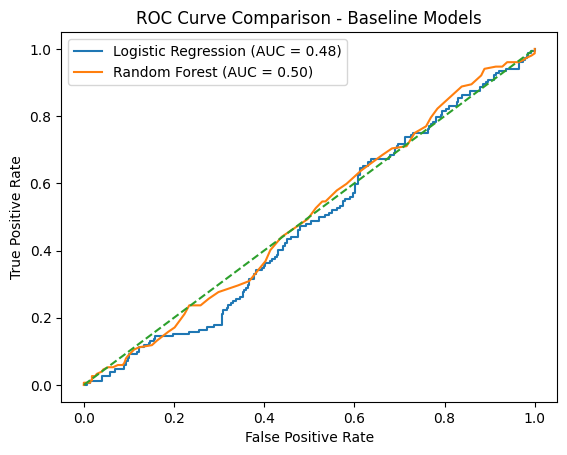

In [8]:
# Logistic Regression probabilities
y_probs_log_life = log_model_life.predict_proba(X_val_life)[:, 1]
fpr_log_life, tpr_log_life, _ = roc_curve(y_val_life, y_probs_log_life)
roc_auc_log_life = auc(fpr_log_life, tpr_log_life)

# Random Forest probabilities
y_probs_rf_life = rf_model_life.predict_proba(X_val_life)[:, 1]
fpr_rf_life, tpr_rf_life, _ = roc_curve(y_val_life, y_probs_rf_life)
roc_auc_rf_life = auc(fpr_rf_life, tpr_rf_life)

# Plot both ROC curves
plt.figure()

plt.plot(fpr_log_life, tpr_log_life, label=f"Logistic Regression (AUC = {roc_auc_log_life:.2f})")
plt.plot(fpr_rf_life, tpr_rf_life, label=f"Random Forest (AUC = {roc_auc_rf_life:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Baseline Models")
plt.legend()
plt.show()

The ROC curves show that both models have limited performance when using lifestyle features alone. While Random Forest may perform better in classification metrics, logistic regression can still provide competitive probability ranking as reflected in the AUC.

## Full Feature Model

After establishing a baseline with lifestyle features only, we expand the feature set to include clinical and demographic variables.

This allows us to evaluate whether a broader set of patient information improves predictive performance.

In [9]:
# Define full feature set (exclude target and non-numeric identifier)
X_all = df.drop(["Diagnosis", "DoctorInCharge", "PatientID"], axis=1)
y_all = df["Diagnosis"]

# Preview selected features
print(X_all.head())

# Check for missing values
print(X_all.isnull().sum())

# Inspect data types
print(X_all.dtypes)

   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0   73       0          0               2  22.927749        0   
1   89       0          0               0  26.827681        0   
2   73       0          3               1  17.795882        0   
3   74       1          0               1  33.800817        1   
4   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

        MMSE  FunctionalAssessment  MemoryComplaints  BehavioralProblems  \
0  21.463532              6.518877                 0                   0   
1  20.

### Train-Test Split

The full feature dataset is split into training and validation sets to evaluate model performance on unseen data.

In [10]:
# Split data into training and validation sets
X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all,
    y_all, 
    test_size = 0.2,
    random_state = 1,
    stratify = y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled = scaler.transform(X_val_all)

#Check split data
print(X_train_all.shape)
print(y_train_all.shape)


(1719, 32)
(1719,)


### Logistic Regression (Full Features)

We train a logistic regression model using the full feature set. Feature scaling is applied to improve model stability, and class weighting is used to address class imbalance.

In [11]:
#Train full-feature logistic regression model
log_model_all = LogisticRegression(
    random_state = 1,
    max_iter = 3000,
    class_weight = 'balanced',
    solver = 'liblinear'
)

log_model_all.fit(X_train_scaled, y_train_all)

#Run model predictions and evaluate
log_preds_all = log_model_all.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_all))
print(confusion_matrix(y_val_all, log_preds_all))



              precision    recall  f1-score   support

           0       0.89      0.81      0.85       278
           1       0.70      0.82      0.75       152

    accuracy                           0.81       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.81      0.81       430

[[224  54]
 [ 28 124]]


## Regularization Tuning

We test different values of the regularization parameter `C` to see how model performance changes.

Smaller values of `C` apply stronger regularization, which can reduce overfitting but may also lead to underfitting if the model becomes too constrained.

### Logistic Regression with Moderate Regularization (`C = 0.1`)

We first test a moderately stronger regularization setting to determine whether it improves generalization.

In [12]:
# Train regularized logistic regression model (C = 0.1)
log_model_c01 = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=3000,
    C=0.1,
    random_state=42
)

log_model_c01.fit(X_train_scaled, y_train_all)

# Run model predictions and evaluate
log_preds_c01 = log_model_c01.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_c01))
print(confusion_matrix(y_val_all, log_preds_c01))

# Inspect coefficient importance
regularized_importance_c01 = pd.Series(
    log_model_c01.coef_[0],
    index=X_train_all.columns
).sort_values(key=abs, ascending=False)

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       278
           1       0.70      0.82      0.75       152

    accuracy                           0.81       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.81      0.81       430

[[224  54]
 [ 28 124]]


### Logistic Regression with Strong Regularization (`C = 0.01`)

We then test a smaller value of `C` to observe whether stronger regularization improves performance or causes underfitting.

              precision    recall  f1-score   support

           0       0.90      0.78      0.84       278
           1       0.68      0.85      0.75       152

    accuracy                           0.80       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.80      0.81       430

[[217  61]
 [ 23 129]]


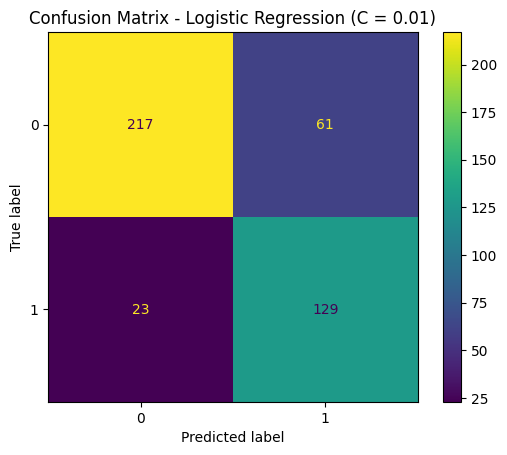

In [13]:
# Train regularized logistic regression model (C = 0.01)
log_model_c001 = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=3000,
    C=0.01,
    random_state=42
)

log_model_c001.fit(X_train_scaled, y_train_all)

# Run model predictions and evaluate
log_preds_c001 = log_model_c001.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_c001))
print(confusion_matrix(y_val_all, log_preds_c001))

#Plot confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix(y_val_all, log_preds_c001))
cm_disp.plot()

plt.title("Confusion Matrix - Logistic Regression (C = 0.01)")

#Save plot
plt.savefig('confusion_matrix_LR.png', bbox_inches = 'tight')
plt.show()

# Inspect coefficient importance
regularized_importance_c001 = pd.Series(
    log_model_c001.coef_[0],
    index=X_train_all.columns
).sort_values(key=abs, ascending=False)

### Tuning Summary

Stronger regularization (`C = 0.01`) improved model performance across multiple metrics, including recall, F1-score, and accuracy.

In particular, the model achieved higher recall for Alzheimer’s cases and reduced the number of false negatives, which is critical in a medical context.

This suggests that a simpler model generalizes better to unseen data, and `C = 0.01` was selected as the final regularization setting.

## Full-Feature Random Forest Model

To compare model performance beyond logistic regression, a Random Forest classifier was trained on the full feature set. This allows evaluation of a non-linear ensemble method alongside the regularized logistic regression model.

Random Forest Classification Report (Full Features):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       278
           1       0.93      0.85      0.89       152

    accuracy                           0.93       430
   macro avg       0.93      0.91      0.92       430
weighted avg       0.93      0.93      0.92       430



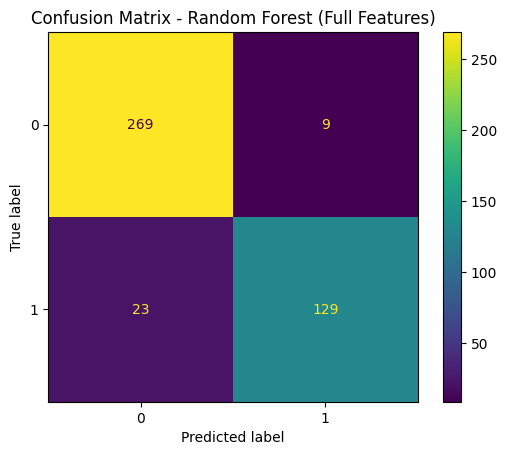

In [14]:
#Train full-feature random forest model
rf_model_all = RandomForestClassifier(
    n_estimators = 200,
    random_state = 1,
    class_weight = 'balanced'
)

rf_model_all.fit(X_train_all, y_train_all)

#Run model predictions and evaluate
rf_preds_all = rf_model_all.predict(X_val_all)
print("Random Forest Classification Report (Full Features):")
print(classification_report(y_val_all, rf_preds_all))

cm_rf_all = confusion_matrix(y_val_all, rf_preds_all)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_rf_all)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Full Features)")

#Save plot
plt.savefig('confusion_matrix_RF.png', bbox_inches = 'tight')
plt.show()

## Tuned Random Forest Model

To further evaluate ensemble performance, a tuned Random Forest classifier was tested using the full feature set. Hyperparameters were adjusted to control model complexity and assess whether tuning could improve generalization compared to the initial Random Forest model.

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       278
           1       0.93      0.87      0.90       152

    accuracy                           0.93       430
   macro avg       0.93      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430



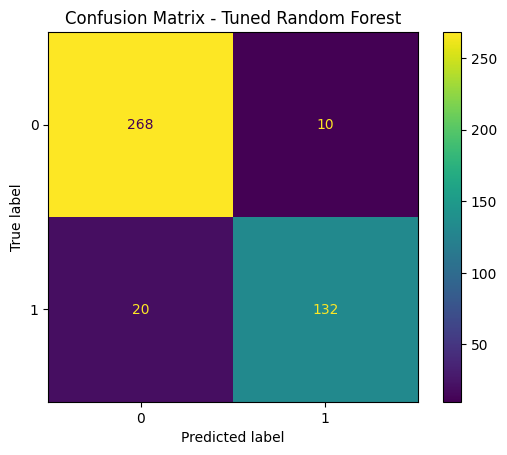

In [15]:
#Train full-feature tuned random forest model
rf_model_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=1,
    class_weight="balanced"
)

rf_model_tuned.fit(X_train_all, y_train_all)

#Run model predictions and evaluate
rf_preds_tuned = rf_model_tuned.predict(X_val_all)
print("Tuned Random Forest Classification Report:")
print(classification_report(y_val_all, rf_preds_tuned))

cm_rf_tuned = confusion_matrix(y_val_all, rf_preds_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned)
disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

Hyperparameter tuning improved recall for Alzheimer’s cases, reducing false negatives while maintaining high overall accuracy. This suggests the tuned model better balances sensitivity and specificity.

## Final ROC Curve

We evaluate and compare the regularized logistic regression model (`C = 0.01`) and the tuned Random Forest model using the ROC curve and AUC metric.

The ROC curve provides a threshold-independent measure of model performance, illustrating each model’s ability to distinguish between Alzheimer’s and non-Alzheimer’s cases across varying classification thresholds. A higher AUC indicates better overall discriminative ability.

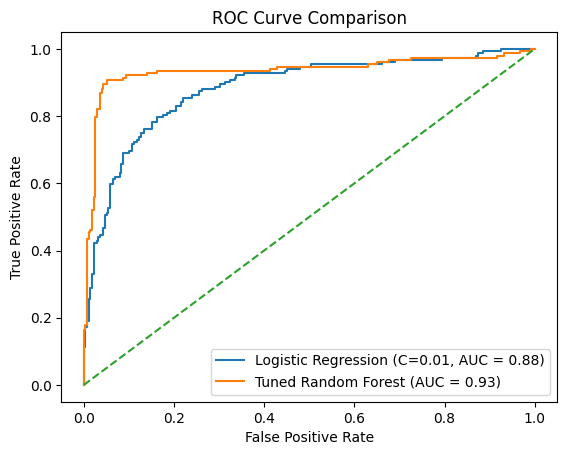

In [16]:
# Generate probabilities for Regularized Logistic Regression
y_probs_regularized = log_model_c001.predict_proba(X_val_scaled)[:, 1]

# Compute ROC for Regularized Logistic Regression
fpr_regularized, tpr_regularized, thresholds_regularized = roc_curve(y_val_all, y_probs_regularized)
roc_auc_final = auc(fpr_regularized, tpr_regularized)

# Generate probabilities for Tuned Random Forest
rf_probs_tuned = rf_model_tuned.predict_proba(X_val_all)[:, 1]

# Compute ROC for Tuned Random Forest
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(y_val_all, rf_probs_tuned)
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)

# Plot ROC curves
plt.figure()
plt.plot(fpr_regularized, tpr_regularized,
         label=f"Logistic Regression (C=0.01, AUC = {roc_auc_final:.2f})")
plt.plot(fpr_rf_tuned, tpr_rf_tuned,
         label=f"Tuned Random Forest (AUC = {roc_auc_rf_tuned:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curve_comparison.png", bbox_inches='tight')
plt.show()

## ROC Curve Comparison

The ROC curve comparison shows that the tuned Random Forest model outperformed the regularized logistic regression model in overall discriminative ability. While both models achieved strong recall for Alzheimer’s cases, the Random Forest demonstrated improved overall classification performance, indicating its ability to capture more complex patterns in the data.

## Feature Importance

We examine the coefficients of the logistic regression model to understand which features contribute most to predicting Alzheimer’s diagnosis.

Positive coefficients indicate a higher likelihood of Alzheimer’s, while negative coefficients indicate a lower likelihood.

FunctionalAssessment       -1.334718
ADL                        -1.252235
MemoryComplaints            1.078220
BehavioralProblems          0.901637
MMSE                       -0.844618
CholesterolLDL             -0.124077
CholesterolTriglycerides    0.109082
CholesterolHDL              0.103791
Smoking                    -0.100966
Confusion                  -0.095813
dtype: float64


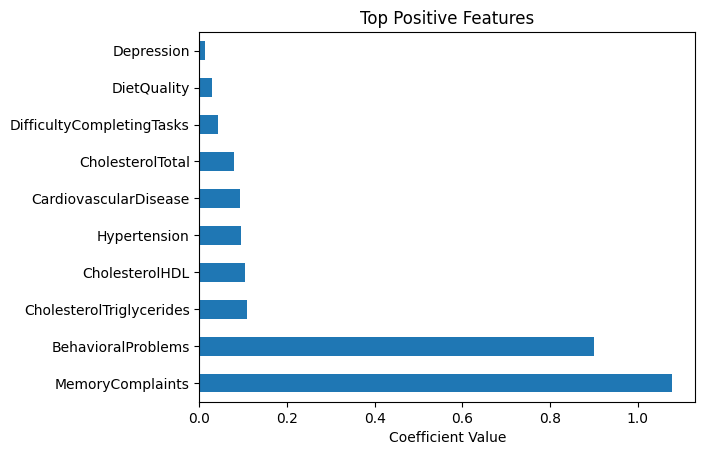

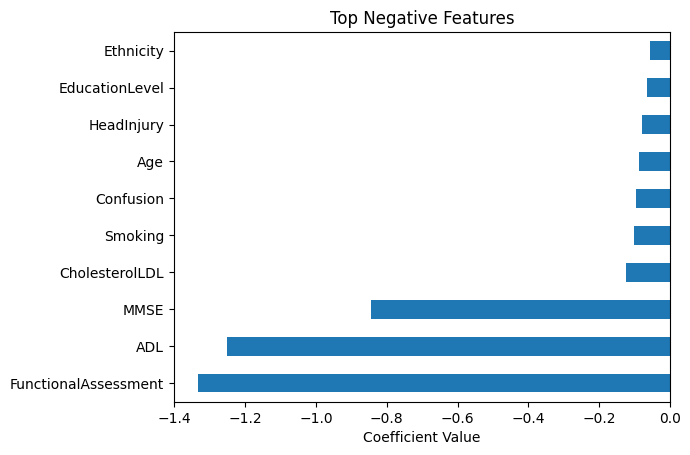

In [17]:
# Feature importance (logistic regression coefficients)
coefficients = pd.Series(
    log_model_all.coef_[0],
    index=X_train_all.columns
)

# Sort by magnitude
coefficients = coefficients.sort_values(key=abs, ascending=False)

print(coefficients.head(10))

# Separate positive and negative features
positive = coefficients[coefficients > 0].sort_values(ascending=False)
negative = coefficients[coefficients < 0].sort_values()

# Plot positive features
plt.figure()
positive.head(10).plot(kind='barh')
plt.title("Top Positive Features")
plt.xlabel("Coefficient Value")
plt.show()

# Plot negative features
plt.figure()
negative.head(10).plot(kind='barh')
plt.title("Top Negative Features")
plt.xlabel("Coefficient Value")
plt.show()

Some features show a negative coefficient despite being positively associated with Alzheimer's. This was due to multicollinearity between highly correlated coginitive symptom variables, causing the model to distribute importance across overlapping predictors. 

## Dimensionality Reduction with PCA

To address potential multicollinearity and explore opportunities for dimensionality reduction, Principal Component Analysis (PCA) was applied after feature standardization. PCA projects the data into a lower-dimensional space defined by orthogonal principal components that maximize variance.

Two PCA configurations were evaluated: one preserving 95% of the variance to assess feature redundancy, and another limiting the feature space to 10 components to test the impact of more aggressive compression. Model performance under these configurations was compared to the full feature model to evaluate tradeoffs between dimensionality and predictive accuracy.

### PCA (95% Variance Retention)

To assess potential feature redundancy and multicollinearity, PCA was applied while retaining 95% of the total variance. This configuration preserves most of the original information while reducing dimensions only where strong correlations exist among features.

In [18]:
#Add PCA
pca_95 = PCA(n_components = 0.95)

#Fit PCA on training data
X_train_pca_95 = pca_95.fit_transform(X_train_scaled)

#Transform validation data using same PCA
X_val_pca_95 = pca_95.transform(X_val_scaled)

#Train model on PCA data
log_model_pca_95 = LogisticRegression(max_iter = 3000, class_weight = 'balanced')
log_model_pca_95.fit(X_train_pca_95, y_train_all)

#Evalaute 
preds_pca_95 = log_model_pca_95.predict(X_val_pca_95)

#Visualize data
print(classification_report(y_val_all, preds_pca_95))
print(confusion_matrix(y_val_all, preds_pca_95))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84       278
           1       0.70      0.80      0.74       152

    accuracy                           0.80       430
   macro avg       0.79      0.80      0.79       430
weighted avg       0.81      0.80      0.81       430

[[225  53]
 [ 31 121]]


### PCA (10 Components)

To explore more aggressive dimensionality reduction, PCA was applied with a fixed number of 10 components. This approach significantly compresses the feature space, allowing evaluation of whether key predictive signals can be preserved in a lower-dimensional representation.

In [19]:
#Add PCA
pca_10 = PCA(n_components = 10)

#Fit PCA on training data
X_train_pca_10 = pca_10.fit_transform(X_train_scaled)

#Transform validation data using same PCA
X_val_pca_10 = pca_10.transform(X_val_scaled)

#Train model on PCA data
log_model_pca_10 = LogisticRegression(max_iter = 3000, class_weight = 'balanced')
log_model_pca_10.fit(X_train_pca_10, y_train_all)

#Evalaute 
preds_pca_10 = log_model_pca_10.predict(X_val_pca_10)

#Visualize data
print(classification_report(y_val_all, preds_pca_10))
print(confusion_matrix(y_val_all, preds_pca_10))

              precision    recall  f1-score   support

           0       0.79      0.74      0.76       278
           1       0.57      0.63      0.60       152

    accuracy                           0.70       430
   macro avg       0.68      0.69      0.68       430
weighted avg       0.71      0.70      0.71       430

[[206  72]
 [ 56  96]]


### PCA Model Comparison

The following table compares the full feature model and both PCA-based models using accuracy, recall, and confusion matrix values.

In [20]:
# Store predictions for each model
model_predictions = {
    "Full Model": log_preds_c001,
    "PCA (95% Variance)": preds_pca_95,
    "PCA (10 Components)": preds_pca_10
}

# Create list to store results
results = []

# Loop through each model and calculate metrics
for model_name, preds in model_predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_val_all, preds).ravel()
    acc = accuracy_score(y_val_all, preds)
    recall_class1 = recall_score(y_val_all, preds)

    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 3),
        "Recall (Class 1)": round(recall_class1, 3),
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn
    })

# Sort by recall
comparison_df = pd.DataFrame(results).sort_values(by="Recall (Class 1)", ascending=False)

# Display table
comparison_df = comparison_df.reset_index(drop=True)
comparison_df

,Model,Accuracy,Recall (Class 1),TP,FN,FP,TN
0,Full Model,0.805,0.849,129,23,61,217
1,PCA (95% Variance),0.805,0.796,121,31,53,225
2,PCA (10 Components),0.702,0.632,96,56,72,206


### Interpretation

- The **full feature model** achieved the best overall performance, particularly in recall, which is critical for identifying Alzheimer’s cases.  
- Applying **PCA with 95% variance retention** preserved overall accuracy but resulted in a noticeable drop in recall, suggesting some important predictive information may have been compressed.  
- Using **only 10 principal components** significantly reduced both accuracy and recall, indicating that excessive dimensionality reduction leads to loss of critical information.  

### Conclusion

PCA did not improve model performance in this case. While it reduced feature dimensionality, it also reduced interpretability and slightly degraded predictive power. The original feature space provided the best balance between performance and interpretability for this dataset.

## Results Summary

- The baseline models using lifestyle features alone showed limited predictive performance.  
- Incorporating clinical and cognitive features significantly improved predictive performance compared to lifestyle features alone.

Final Logistic Regression Model (`C = 0.01`):
- Accuracy: ~0.82  
- Recall (Alzheimer’s): ~0.85  
- AUC: ~0.89  

Tuned Random Forest Model:
- Accuracy: ~0.93  
- Recall (Alzheimer’s): ~0.87  
- Strong precision and overall classification performance  

The tuned Random Forest model outperformed logistic regression in overall accuracy and precision while maintaining comparable recall for Alzheimer’s cases. This indicates that the ensemble model was better able to capture complex, non-linear relationships in the data.

### Impact of Dimensionality Reduction (PCA)

- PCA retaining 95% of the variance resulted in a slight decrease in performance (Accuracy: ~0.79, Recall: ~0.75), indicating that some important predictive information was lost despite minimal dimensionality reduction.  
- PCA with 10 components led to a substantial drop in performance (Accuracy: ~0.65, Recall: ~0.65), suggesting that aggressive dimensionality reduction removed critical features necessary for accurate classification.  

Overall, these results indicate that the dataset does not exhibit high redundancy, and that preserving the full feature set yields the best predictive performance, particularly when prioritizing recall to minimize missed Alzheimer’s diagnoses.

## Conclusion

This project demonstrates that:

- Clinical and cognitive features significantly improve Alzheimer’s prediction compared to lifestyle features alone.  
- Regularization plays an important role in improving logistic regression performance and generalization.  
- Ensemble models such as Random Forest can capture more complex, non-linear relationships in the data and achieve superior predictive performance.  
- Dimensionality reduction through PCA did not improve model performance, suggesting that the dataset does not contain substantial feature redundancy and that preserving the full feature space is important for maintaining predictive accuracy. 

While logistic regression with regularization (`C = 0.01`) provided a strong and interpretable baseline model, the tuned Random Forest achieved the best overall performance, with higher accuracy and improved recall for Alzheimer’s cases. This reduction in false negatives is particularly important in a clinical context, where missed diagnoses carry significant consequences.

These results highlight the trade-off between interpretability and predictive performance: logistic regression offers transparency in feature importance, while Random Forest provides stronger predictive capability.

Overall, the project shows that clinically relevant features are much more informative than lifestyle variables alone, and that tree-based ensemble methods can provide especially strong predictive performance for this classification task.

## Future Improvements

- Perform more extensive hyperparameter tuning using methods such as GridSearchCV  
- Explore additional models such as Gradient Boosting or XGBoost  
- Apply cross-validation for more robust evaluation  
- Investigate feature interactions and assess potential multicollinearity effects  